In [1]:
!hostname

gnode011.cluster


In [2]:
!nvidia-smi

Mon Mar 17 16:22:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:31:00.0 Off |                    0 |
| N/A   26C    P0             41W /  300W |       1MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import itertools as it
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sdeint
from toolbox import (
    make_loss,
    StatLoss,
    SINN,
    FPU
)
import time

In [4]:
torch.cuda.is_available()

True

In [5]:
device = torch.device('cuda')

In [6]:
print(torch.__version__)
print(torch.version.cuda)

2.0.1+cu118
11.8


In [7]:
seed = 1234
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

In [11]:
# Parameters
A = 0.5                   # Driving strength
Omega = 1.0               # Frequency of oscillation
D = 1/40                # Fluctuation strength
gamma = 1.0               # Damping coefficient
batch = 100000               # Batch size
sec_length = 800          # Length of input sequence

In [13]:
def V(x, t, A, Omega):
    return -0.5 * x**2 + 0.25 * x**4 - A * x * np.sin(Omega * t)

In [14]:
def dV_dx(x, t, A, Omega):
    return -x + x**3 - A * np.sin(Omega * t)

In [15]:
# Euler-Maruyama scheme
def euler_maruyama(dt, delta_t, total_time, batch):
    length = int(total_time / dt) + 1
    t = np.linspace(0, total_time, length)
    gap = int(delta_t / dt)
    t_store = t[0:-1:gap]
    q_store = np.zeros([t_store.size + 1, batch])
    q = np.zeros((2, batch))  # q[0,:] = position, q[1,:] = velocity (temporary)
    
    j = 1
    for i in range(1, length):
        q[1, :] = q[0, :] - dV_dx(q[0, :], i * dt, A, Omega) * dt \
                  + np.random.randn(1, batch) * np.sqrt(2 * dt * D)
        
        if i % gap == 0:
            q_store[j, :] = q[1, :]
            j = j + 1
            
        q[0, :] = q[1, :]
        
        
#     return q_store

    Toss = int(t_store.size / 2)
    print(Toss)
    return q_store[Toss:-1, :]  # Remove transients


In [16]:
# Reference solution (very small dt)
dt_ref = 0.0001
delta_t = 0.2
# total_time = 4*delta_t*sec_length
total_time = 2*np.pi
q_ref = euler_maruyama(dt_ref, delta_t, total_time, batch)

16


In [17]:
# Moments of the reference solution
mean_ref = np.mean(q_ref[:,:], axis = 1)
var_ref = np.var(q_ref[:,:], axis = 1)

In [18]:
print(np.mean(q_ref[-1,:]))

0.5559104669859944


In [19]:
print(mean_ref[-1])

0.5559104669859944


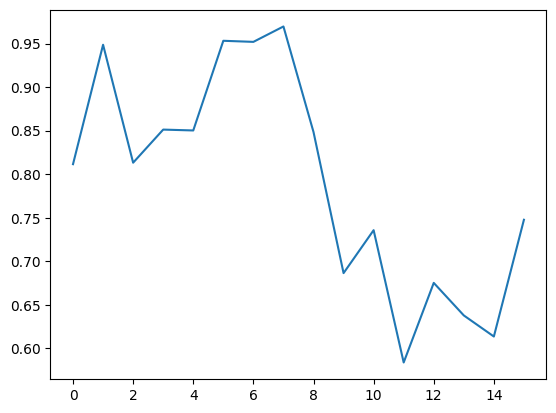

In [20]:
plt.plot(q_ref[:,-1])

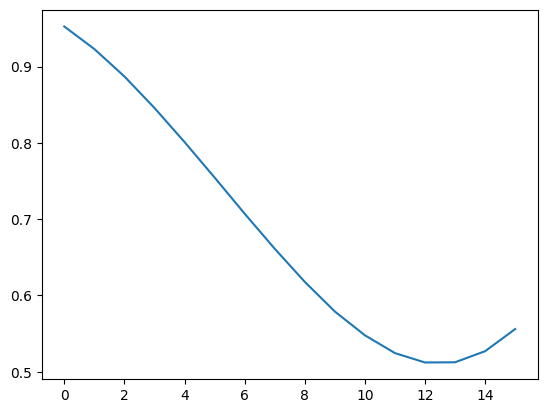

In [21]:
plt.plot(mean_ref)

In [22]:
print(mean_ref.shape)

(16,)


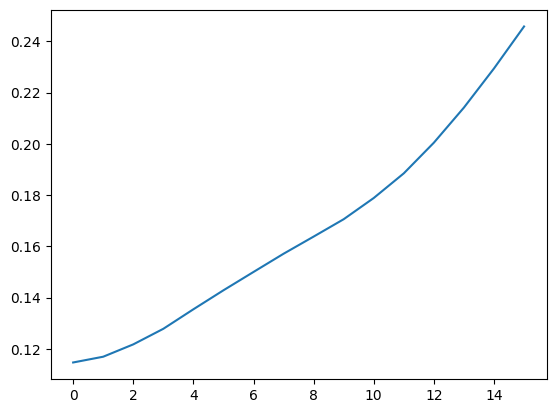

In [23]:
plt.plot(var_ref)

0.1
15
(16,)


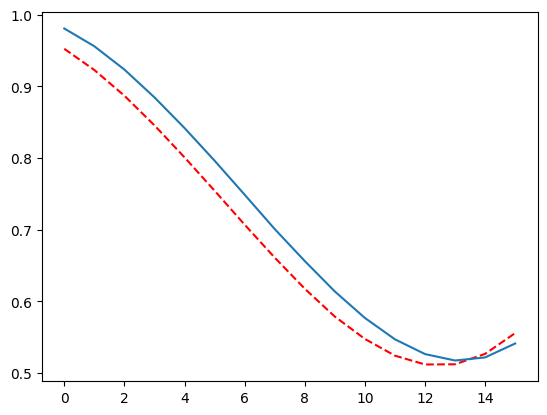

0.05
16
(16,)


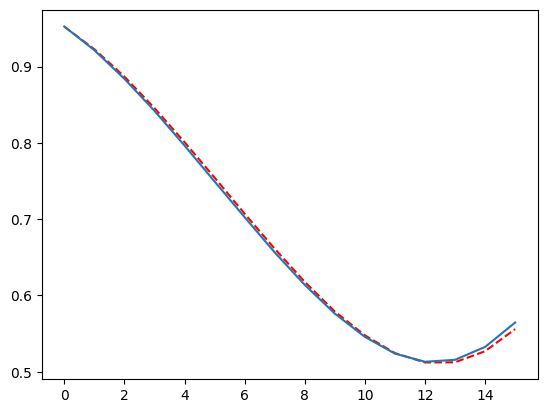

0.01
16
(16,)


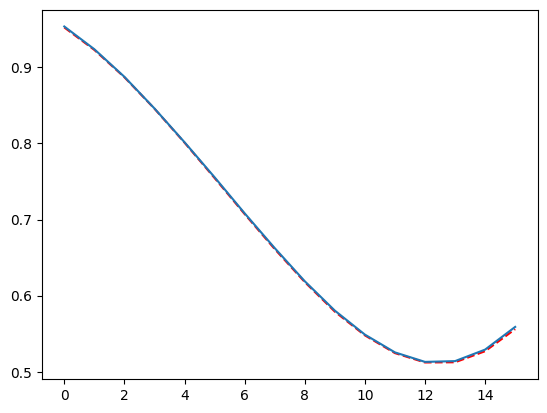

0.005
16
(16,)


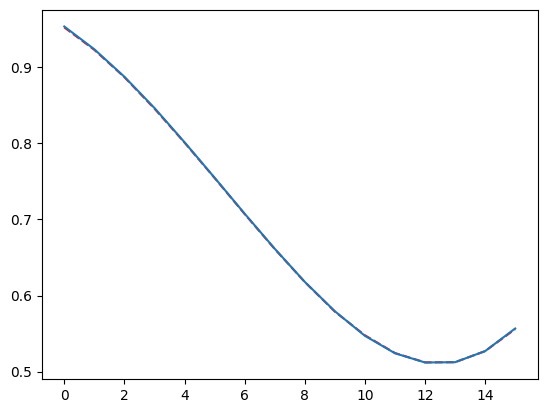

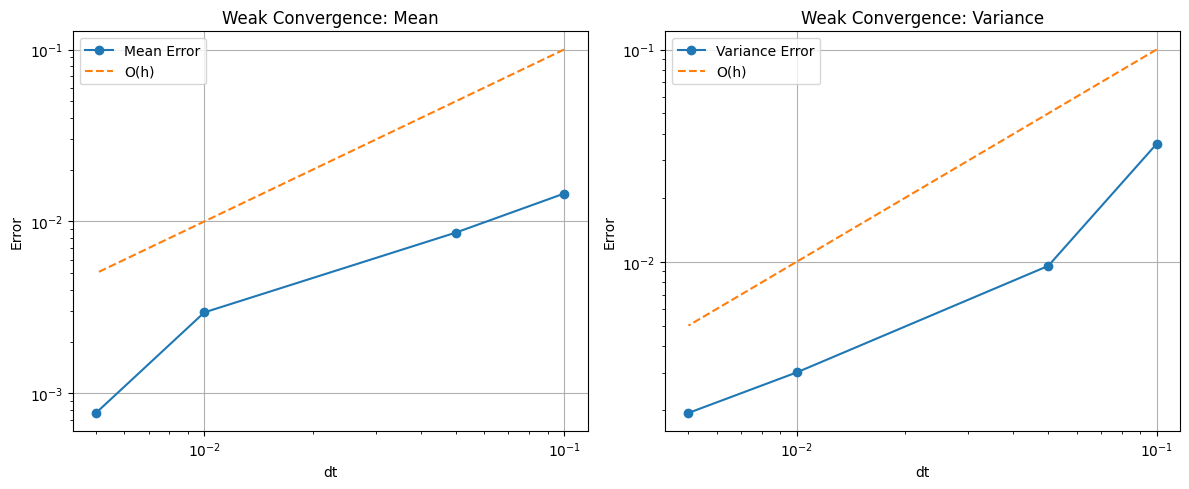

In [24]:
# Compare with coarser time steps
dt_list = [0.1, 0.05, 0.01, 0.005]
errors_mean = []
errors_var = []

for dt in dt_list:
    print(dt)
    q_num = euler_maruyama(dt, delta_t, total_time, batch)
    mean_num = np.mean(q_num[:,:], axis = 1)
    var_num = np.var(q_num[:,:], axis = 1)
    print(mean_num.shape)
    plt.plot(mean_ref,'r--')
    plt.plot(mean_num)
    plt.show()
    

    
    # Compute errors (e.g., L2 norm of the difference)
    error_mean = np.abs(mean_num[-1] - mean_ref[-1])
    error_var = np.abs(var_num[-1] - var_ref[-1])
    
    errors_mean.append(error_mean)
    errors_var.append(error_var)

# Plot errors vs dt on a log-log scale
plt.figure(figsize=(12, 5))

# Mean error
plt.subplot(1, 2, 1)
plt.loglog(dt_list, errors_mean, '-o', label='Mean Error')
plt.loglog(dt_list, [dt for dt in dt_list], linestyle='--', label='O(h)')
plt.xlabel('dt')
plt.ylabel('Error')
plt.title('Weak Convergence: Mean')
plt.grid(True)
plt.legend()

# Variance error
plt.subplot(1, 2, 2)
plt.loglog(dt_list, errors_var, '-o', label='Variance Error')
plt.loglog(dt_list, [dt for dt in dt_list], linestyle='--', label='O(h)')
plt.xlabel('dt')
plt.ylabel('Error')
plt.title('Weak Convergence: Variance')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


0.1
15
(16,)


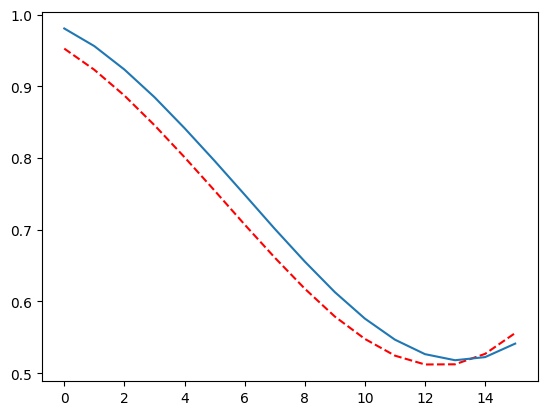

0.05
16
(16,)


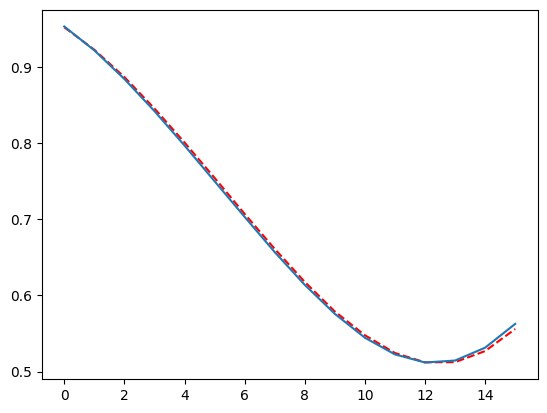

0.01
16
(16,)


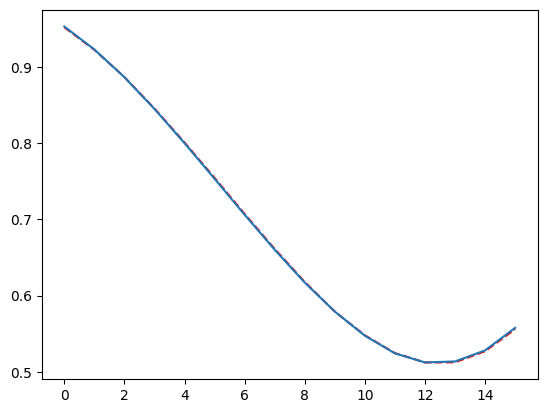

0.005
16
(16,)


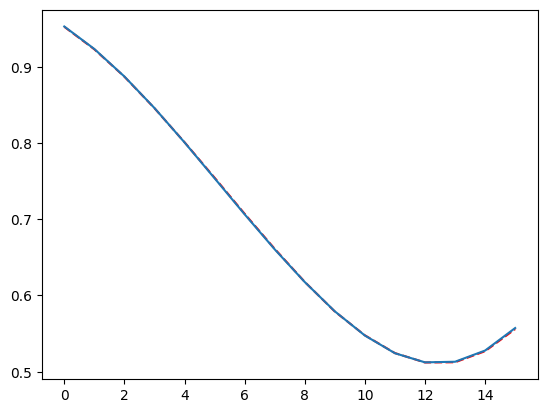

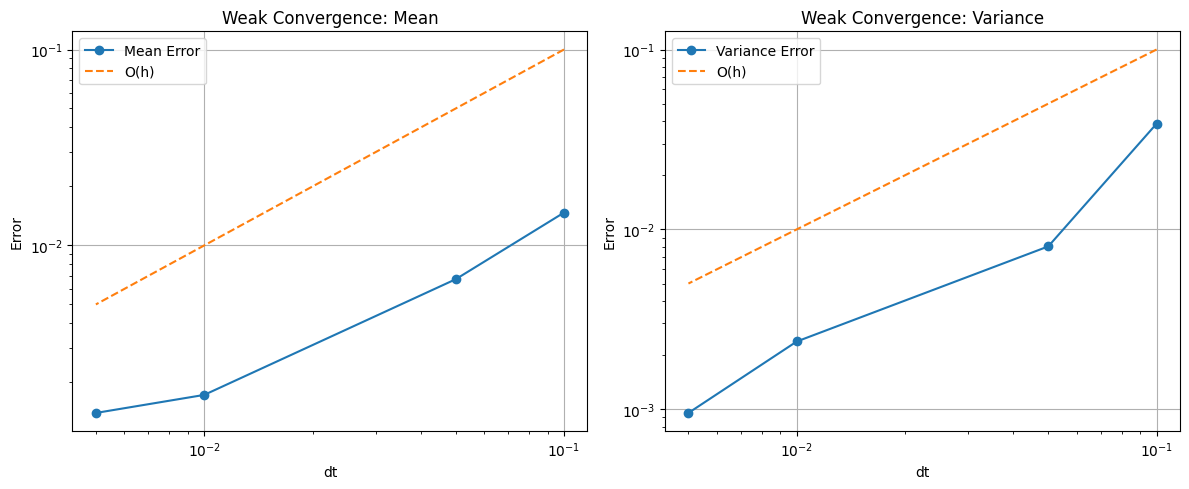

In [25]:
# Compare with coarser time steps
dt_list = [0.1, 0.05, 0.01, 0.005]
errors_mean = []
errors_var = []

for dt in dt_list:
    print(dt)
    q_num = euler_maruyama(dt, delta_t, total_time, batch)
    mean_num = np.mean(q_num[:,:], axis = 1)
    var_num = np.var(q_num[:,:], axis = 1)
    print(mean_num.shape)
    plt.plot(mean_ref,'r--')
    plt.plot(mean_num)
    plt.show()
    

    
    # Compute errors (e.g., L2 norm of the difference)
    error_mean = np.abs(mean_num[-1] - mean_ref[-1])
    error_var = np.abs(var_num[-1] - var_ref[-1])
    
    errors_mean.append(error_mean)
    errors_var.append(error_var)

# Plot errors vs dt on a log-log scale
plt.figure(figsize=(12, 5))

# Mean error
plt.subplot(1, 2, 1)
plt.loglog(dt_list, errors_mean, '-o', label='Mean Error')
plt.loglog(dt_list, [dt for dt in dt_list], linestyle='--', label='O(h)')
plt.xlabel('dt')
plt.ylabel('Error')
plt.title('Weak Convergence: Mean')
plt.grid(True)
plt.legend()

# Variance error
plt.subplot(1, 2, 2)
plt.loglog(dt_list, errors_var, '-o', label='Variance Error')
plt.loglog(dt_list, [dt for dt in dt_list], linestyle='--', label='O(h)')
plt.xlabel('dt')
plt.ylabel('Error')
plt.title('Weak Convergence: Variance')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
